In [2]:
import os
os.environ['PATH']

'/home/glaswigian/miniconda3/envs/Huggingface/bin:/home/glaswigian/miniconda3/condabin:/home/glaswigian/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin'

In [3]:
import logging
from pathlib import Path
from transformers import AutoConfig, AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, DataCollatorForLanguageModeling, TrainerCallback
from datasets import load_dataset
from perf_estimator.trainer.plugins import ProfilerCallback, SnapshotCallback

/home/glaswigian/miniconda3/envs/Huggingface/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

os.environ["NCCL_P2P_DISABLE"] = "1"
os.environ["NCCL_IB_DISABLE"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"


In [4]:
# Configure logging
# ---------------------------
# 1. Model Initialization (from scratch)
# ---------------------------
# We use the configuration of a popular small-scale LLM (facebook/opt-125m)
# but initialize the model randomly (i.e. train from scratch)
model_name = "facebook/opt-125m"
# model_name = "EleutherAI/gpt-neo-125M"
model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
config = AutoConfig.from_pretrained(model_name)  # load config; do NOT load pretrained weights
model = AutoModelForCausalLM.from_config(config)   # randomly initialized model
print(model)

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotary_emb): Qw

In [5]:
# Load tokenizer (we can reuse the pretrained tokenizer)
tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token  # assign PAD token if missing

# Enable gradient checkpointing to reduce memory usage (at the cost of additional compute)
model.gradient_checkpointing_enable()

# ---------------------------
# 2. Dataset Preparation
# ---------------------------
# Load the Wikitext-2 dataset as our general-purpose text corpus.
# For a quick profiling run, we use only a small subset.
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")
train_dataset = dataset["train"].select(range(1000))  # limit to 1000 examples for this demo

# Tokenization: convert text to token IDs (truncated to a maximum length)
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, max_length=128)

tokenized_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# Data collator: handles padding and prepares labels for causal LM (labels equal to input_ids)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# ---------------------------
# 3. Trainer Setup with Memory Profiling Callback
# ---------------------------
# TrainingArguments are set to run only 3 steps and use a small batch size suitable for an 8–12GB GPU.
training_args = TrainingArguments(
    output_dir="output",
    # per_device_train_batch_size=2,
    max_steps=3,  # run only 3 training iterations for profiling
    gradient_accumulation_steps=1,
    fp16=False,  # using full precision; set True if your GPU supports mixed precision to save memory
    logging_steps=1,
    report_to=[],  # disable external logging (e.g., wandb)
    disable_tqdm=False,
    use_cpu=True,
    do_train=True,
    do_eval=False,
    save_strategy="no"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator,
    callbacks=[ProfilerCallback(), SnapshotCallback()],
)

# ---------------------------
# 4. Training with PyTorch Profiler
# ---------------------------

trainer.train()  # run 3 training iterations

# Print a summary of the profiler's memory usage by CUDA operation (top 10 ops)
print("Profiler Memory Usage Summary (top CUDA ops):")


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Starting profiler...


Step,Training Loss
1,12.094900
2,0.000000
3,0.000000


[W311 00:31:00.105861516 CPUAllocator.cpp:245] Memory block of unknown size was allocated before the profiling started, profiler results will not include the deallocation event


Stopping profiler...
Profiler Memory Usage Summary (top CUDA ops):


In [5]:
from ures.files import filter_files
p_file = filter_files("pt.trace.json", str(Path().home().joinpath("DL-Estimator")), fuzz=True)[-1]
p_file


'/home/glaswigian/DL-Estimator/20250311-002944-8b21/results/callback/Profiler/Glaswigian-Researcher_6983.1741653118566962650.pt.trace.json'

Duplicate layer name found: Qwen2DecoderLayer_27. Renaming to Qwen2DecoderLayer_27_d3
Duplicate layer name found: Qwen2RMSNorm_54. Renaming to Qwen2RMSNorm_54_11
Duplicate layer name found: Qwen2Attention_27. Renaming to Qwen2Attention_27_32
Duplicate layer name found: Linear_189. Renaming to Linear_189_b3
Duplicate layer name found: Linear_190. Renaming to Linear_190_c3
Duplicate layer name found: Linear_191. Renaming to Linear_191_ef
Duplicate layer name found: Linear_192. Renaming to Linear_192_92
Duplicate layer name found: Qwen2RMSNorm_55. Renaming to Qwen2RMSNorm_55_00
Duplicate layer name found: Qwen2MLP_27. Renaming to Qwen2MLP_27_69
Duplicate layer name found: Linear_193. Renaming to Linear_193_78
Duplicate layer name found: SiLU_27. Renaming to SiLU_27_f5
Duplicate layer name found: Linear_194. Renaming to Linear_194_0f
Duplicate layer name found: Linear_195. Renaming to Linear_195_69
Duplicate layer name found: Qwen2DecoderLayer_26. Renaming to Qwen2DecoderLayer_26_65
Duplic

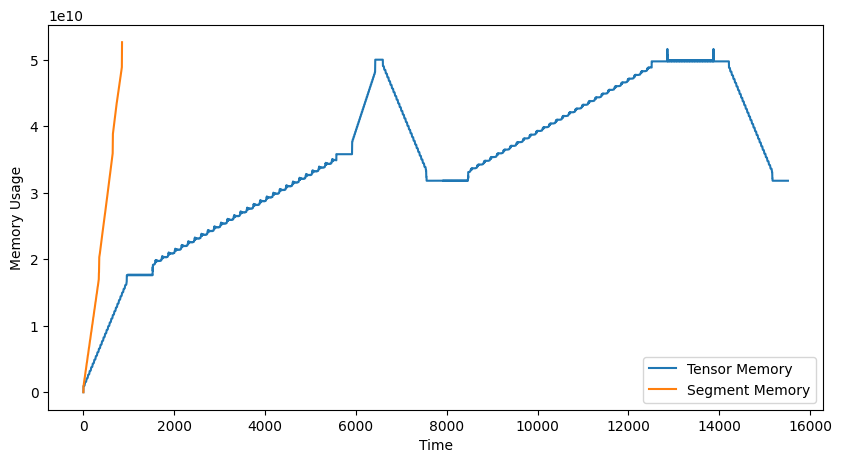

Profiler file: /home/glaswigian/DL-Estimator/20250311-002944-8b21/results/callback/Profiler/Glaswigian-Researcher_6983.1741653118566962650.pt.trace.json
{'OOM': False, 'Max GPU Memory': 68719476736, 'memory': {'tensor': 51627986944, 'segment': 52642709504}, 'runtime': 56.63}


In [12]:
from perf_estimator.xmem import XMem
xmen = XMem(
    batch_size=1,
    max_gpu_memory_in_gb=64,
)
result = xmen.estimate(
    profiler_file=p_file, trainer_enable=True, output_only=True
)
print(f"Profiler file: {p_file}")
print(result)


In [6]:
from perf_estimator.estimator import TrainerEstimator
from perf_estimator.dataset import image_dataset
estimator = TrainerEstimator(
    dataloader=image_dataset(batch=100),
    profiler_file=p_file,
    max_gpu_memory_in_gb=64,
)
allocator, est_result = estimator.estimate()

Duplicate layer name found: Qwen2DecoderLayer_27. Renaming to Qwen2DecoderLayer_27_43
Duplicate layer name found: Qwen2RMSNorm_54. Renaming to Qwen2RMSNorm_54_12
Duplicate layer name found: Qwen2Attention_27. Renaming to Qwen2Attention_27_59
Duplicate layer name found: Linear_189. Renaming to Linear_189_8f
Duplicate layer name found: Linear_190. Renaming to Linear_190_87
Duplicate layer name found: Linear_191. Renaming to Linear_191_5f
Duplicate layer name found: Linear_192. Renaming to Linear_192_25
Duplicate layer name found: Qwen2RMSNorm_55. Renaming to Qwen2RMSNorm_55_e5
Duplicate layer name found: Qwen2MLP_27. Renaming to Qwen2MLP_27_ad
Duplicate layer name found: Linear_193. Renaming to Linear_193_7f
Duplicate layer name found: SiLU_27. Renaming to SiLU_27_bd
Duplicate layer name found: Linear_194. Renaming to Linear_194_49
Duplicate layer name found: Linear_195. Renaming to Linear_195_ef
Duplicate layer name found: Qwen2DecoderLayer_26. Renaming to Qwen2DecoderLayer_26_f5
Duplic

In [7]:
_allocator, _ = estimator.estimate_memory_blocks(estimator.model_memory(iteration_index=1, reset=True))

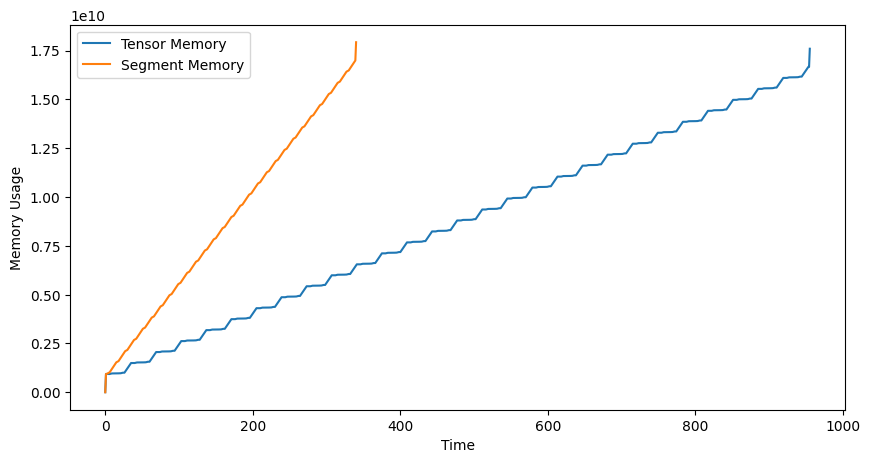

In [8]:
_allocator.plot_memory_change()